In [32]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

from utils.post_training import *
from utils.statistics import *
from utils.plotting import *
from utils.encodings import *
from utils.haar_noising_script import apply_haar_scrambling

import numpy as np
import h5py
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.linalg

import pennylane as qml

/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model


In [33]:
QG_channel = 1
filename = f"data/QG{QG_channel}_64x64_1k"
# filename = f"data/QG{QG_channel}_16x16_1k"
with h5py.File(filename, "r") as f:
    data_X = np.array(f["X"])

# If the dataset includes channels, select the requested QG channel (1-indexed)
if data_X.ndim == 4:
    data_X = data_X[..., QG_channel - 1]

# Preprocess like other notebooks: log, normalize, map to [-1, 1]
data_X = data_X.astype(np.float32)
data_X = np.log1p(data_X)
data_X = data_X / data_X.max()
data_X = 2.0 * data_X - 1.0

print("Dataset shape:", data_X.shape, "min:", data_X.min(), "max:", data_X.max())


Dataset shape: (1000, 64, 64) min: -1.0 max: 1.0


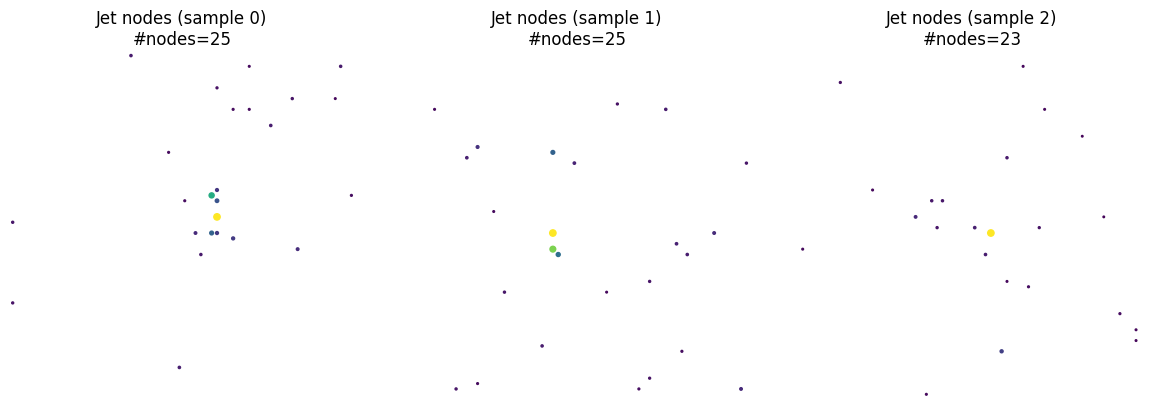

In [34]:
# --- Visualize jet-structure learning target (energy-based nodes only) ---

def _to_single_channel(sample, channel=0):
    if sample.ndim == 3:
        return sample[..., channel]
    return sample

def _normalize_for_graph(img):
    img = img.astype(np.float32)
    if img.min() < 0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    elif img.max() > 1.0:
        img = img / (img.max() + 1e-12)
    return img

def extract_energy_nodes(img, energy_quantile=0.995):
    """
    Keep the minimal set of highest-intensity pixels whose cumulative
    energy reaches the given quantile. Each pixel is its own node.
    """
    img_n = _normalize_for_graph(img)
    flat = img_n.flatten()
    total = flat.sum()

    if total <= 0:
        return img_n, np.empty((0, 2)), np.array([])

    order = np.argsort(flat)[::-1]  # descending by intensity
    cumsum = np.cumsum(flat[order])
    cutoff_idx = np.searchsorted(cumsum, energy_quantile * total)
    keep_idx = order[:cutoff_idx + 1]

    coords = np.column_stack(np.unravel_index(keep_idx, img_n.shape))
    intens = flat[keep_idx]

    return img_n, coords, intens

def plot_energy_nodes(ax, img, energy_quantile=0.995, cmap="viridis"):
    img_n, coords, intens = extract_energy_nodes(img, energy_quantile=energy_quantile)
    H, W = img_n.shape

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

    if intens.size == 0:
        return 0

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(coords[:, 1], coords[:, 0], s=sizes, c=intens, cmap=cmap, vmin=0, vmax=intens.max())
    return len(intens)

num_samples_to_plot = 3
sample_indices = list(range(num_samples_to_plot))

fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 4))
if num_samples_to_plot == 1:
    axes = [axes]

for i, idx in enumerate(sample_indices):
    sample = _to_single_channel(data_X[idx], channel=0)
    n_nodes = plot_energy_nodes(axes[i], sample, energy_quantile=0.995)
    axes[i].set_title(f"Jet nodes (sample {idx})\n#nodes={n_nodes}")

plt.tight_layout()
plt.show()


In [41]:
# --- (1) Fixed-length node set with mask (energy-based foreground only) ---
energy_quantile = 0.995
K_max = 256  # max nodes per jet; tune as needed
num_samples_for_nodes = min(1000, data_X.shape[0])
log_eps = 1e-6

def nodes_to_fixed(coords, intens, H, W, K_max):
    """Convert variable-length nodes to fixed-length (K_max, 3) with mask."""
    if intens.size == 0:
        return (
            np.zeros((K_max, 3), dtype=np.float32),
            np.zeros((K_max,), dtype=np.float32),
            0,
            np.array([0.0, 0.0], dtype=np.float32),
        )

    order = np.argsort(intens)[::-1]
    coords = coords[order]
    intens = intens[order]

    # Normalize coordinates to [-1, 1]
    xs = coords[:, 1] / (W - 1 + 1e-12)
    ys = coords[:, 0] / (H - 1 + 1e-12)
    xs = 2.0 * xs - 1.0
    ys = 2.0 * ys - 1.0

    # Center by intensity-weighted centroid
    w = intens / (intens.sum() + 1e-12)
    cx = np.sum(xs * w)
    cy = np.sum(ys * w)
    xs = xs - cx
    ys = ys - cy

    # Log-intensity target (<= 0)
    intens_log = np.log(intens + log_eps)

    feats = np.stack([xs, ys, intens_log], axis=1).astype(np.float32)
    n = min(len(feats), K_max)

    out = np.zeros((K_max, 3), dtype=np.float32)
    mask = np.zeros((K_max,), dtype=np.float32)
    out[:n] = feats[:n]
    mask[:n] = 1.0
    return out, mask, n, np.array([cx, cy], dtype=np.float32)

nodes_all = np.zeros((num_samples_for_nodes, K_max, 3), dtype=np.float32)
mask_all = np.zeros((num_samples_for_nodes, K_max), dtype=np.float32)
lengths = np.zeros((num_samples_for_nodes,), dtype=np.int32)
centroids = np.zeros((num_samples_for_nodes, 2), dtype=np.float32)
radials = np.zeros((num_samples_for_nodes,), dtype=np.float32)
radial_stds = np.zeros((num_samples_for_nodes,), dtype=np.float32)
nn_means = np.zeros((num_samples_for_nodes,), dtype=np.float32)

for i in range(num_samples_for_nodes):
    sample = _to_single_channel(data_X[i], channel=0)
    img_n, coords, intens = extract_energy_nodes(sample, energy_quantile=energy_quantile)
    H, W = img_n.shape
    nodes, mask, n, center = nodes_to_fixed(coords, intens, H, W, K_max)
    nodes_all[i] = nodes
    mask_all[i] = mask
    lengths[i] = n
    centroids[i] = center

    if n > 0:
        xs = nodes[:n, 0]
        ys = nodes[:n, 1]
        intens_lin = np.exp(nodes[:n, 2])
        w = intens_lin / (intens_lin.sum() + 1e-12)
        r = np.sqrt(xs**2 + ys**2)
        r_mean = np.sum(r * w) / np.sqrt(2.0)
        radials[i] = r_mean
        r_var = np.sum(((r - r_mean) ** 2) * w)
        radial_stds[i] = np.sqrt(r_var)

        if n > 1:
            coords_xy = np.stack([xs, ys], axis=1)
            diff = coords_xy[:, None, :] - coords_xy[None, :, :]
            dist = np.sqrt((diff ** 2).sum(axis=2))
            np.fill_diagonal(dist, np.inf)
            nn_means[i] = np.mean(np.min(dist, axis=1))
        else:
            nn_means[i] = 0.0
    else:
        radials[i] = 0.0
        radial_stds[i] = 0.0
        nn_means[i] = 0.0

print("Nodes tensor:", nodes_all.shape, "Mask tensor:", mask_all.shape)
print("Avg #nodes:", lengths.mean(), "Max #nodes:", lengths.max())

# torch tensors for modeling
nodes_t = torch.tensor(nodes_all, dtype=torch.float32)
mask_t = torch.tensor(mask_all, dtype=torch.float32)
counts_t = torch.tensor(lengths / K_max, dtype=torch.float32).unsqueeze(1)
radials_t = torch.tensor(radials, dtype=torch.float32).unsqueeze(1)
radial_stds_t = torch.tensor(radial_stds, dtype=torch.float32).unsqueeze(1)
nn_means_t = torch.tensor(nn_means, dtype=torch.float32).unsqueeze(1)
centroids_t = torch.tensor(centroids, dtype=torch.float32)


Nodes tensor: (1000, 256, 3) Mask tensor: (1000, 256)
Avg #nodes: 22.761 Max #nodes: 59


In [46]:
# --- (2) Foreground-only flow matching model (count + radial + centroid conditioned) ---
device = "mps" if torch.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

features_per_node = 3
dim = K_max * features_per_node

# Flatten nodes to a fixed vector per sample
x0 = nodes_t.view(nodes_t.shape[0], -1).to(device)
mask_flat = mask_t.view(mask_t.shape[0], -1).to(device)  # (B, K_max)
mask_feat = mask_flat.repeat_interleave(features_per_node, dim=1)
counts_t = counts_t.to(device)
radials_t = radials_t.to(device)
radial_stds_t = radial_stds_t.to(device)
nn_means_t = nn_means_t.to(device)
centroids_t = centroids_t.to(device)

def timestep_embedding(t, dim=64):
    """Sinusoidal time embedding. t: (B,1) in [0,1]."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

def count_embedding(c, dim=32):
    """Sinusoidal embedding for count (normalized to [0,1])."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=c.device) / (half - 1))
    args = c * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

def radial_embedding(r, dim=16):
    """Sinusoidal embedding for mean radius (normalized to [0,1])."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=r.device) / (half - 1))
    args = r * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

def radial_std_embedding(rs, dim=16):
    """Sinusoidal embedding for radius std (normalized)."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=rs.device) / (half - 1))
    args = rs * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

def centroid_embedding(cxy, dim=16):
    """Sinusoidal embedding for centroid (x,y)."""
    # cxy: (B,2) in [-1,1]
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=cxy.device) / (half - 1))
    args_x = cxy[:, [0]] * freqs
    args_y = cxy[:, [1]] * freqs
    emb_x = torch.cat([torch.sin(args_x), torch.cos(args_x)], dim=-1)
    emb_y = torch.cat([torch.sin(args_y), torch.cos(args_y)], dim=-1)
    return torch.cat([emb_x, emb_y], dim=-1)

class SimpleFlowMLP(nn.Module):
    def __init__(self, dim, nodes, hidden=512, time_dim=64, count_dim=32, radial_dim=16, radial_std_dim=16, centroid_dim=16):
        super().__init__()
        self.time_dim = time_dim
        self.count_dim = count_dim
        self.radial_dim = radial_dim
        self.radial_std_dim = radial_std_dim
        self.centroid_dim = centroid_dim
        self.backbone = nn.Sequential(
            nn.Linear(dim + time_dim + count_dim + radial_dim + radial_std_dim + 2 * centroid_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )
        self.v_head = nn.Linear(hidden, dim)
        self.mask_head = nn.Linear(hidden, nodes)

    def forward(self, x, t, c, r, rs, cxy):
        t_emb = timestep_embedding(t, self.time_dim)
        c_emb = count_embedding(c, self.count_dim)
        r_emb = radial_embedding(r, self.radial_dim)
        rs_emb = radial_std_embedding(rs, self.radial_std_dim)
        cxy_emb = centroid_embedding(cxy, self.centroid_dim)
        h = torch.cat([x, t_emb, c_emb, r_emb, rs_emb, cxy_emb], dim=-1)
        h = self.backbone(h)
        v = self.v_head(h)
        mask_logits = self.mask_head(h)
        return v, mask_logits

model = SimpleFlowMLP(dim=dim, nodes=K_max, hidden=512, time_dim=64, count_dim=32, radial_dim=16, radial_std_dim=16, centroid_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Simple rectified-flow training loop (masked)
batch_size = 32
num_steps = 500
mask_weight = 1.0
count_weight = 1.0
radial_weight = 1.0
nn_weight = 1.0
shrink_weight = 0.5
radial_hist_weight = 0.5

for step in range(num_steps):
    idx = torch.randint(0, x0.shape[0], (batch_size,), device=device)
    x = x0[idx]
    m_feat = mask_feat[idx]
    m = mask_flat[idx]
    c = counts_t[idx]
    r = radials_t[idx]
    rs = radial_stds_t[idx]
    nn_tgt = nn_means_t[idx]
    cxy = centroids_t[idx]
    t = torch.rand(batch_size, 1, device=device)

    x1 = torch.randn_like(x)
    xt = (1 - t) * x + t * x1
    v_target = x1 - x
    v_pred, mask_logits = model(xt, t, c, r, rs, cxy)

    # Masked MSE for flow (ignore padded nodes)
    loss_flow = ((v_pred - v_target) ** 2 * m_feat).sum() / (m_feat.sum() + 1e-12)
    loss_mask = F.binary_cross_entropy_with_logits(mask_logits, m)
    count_pred = torch.sigmoid(mask_logits).sum(dim=1, keepdim=True) / K_max
    loss_count = ((count_pred - c) ** 2).mean()

    # Radial consistency loss on x0_hat
    x0_hat = xt - t * v_pred
    nodes_hat = x0_hat.view(-1, K_max, 3)
    xs_hat = nodes_hat[..., 0]
    ys_hat = nodes_hat[..., 1]
    intens_hat = torch.exp(nodes_hat[..., 2]) * m
    w_sum = intens_hat.sum(dim=1, keepdim=True) + 1e-12
    r_hat = torch.sqrt(xs_hat**2 + ys_hat**2) / np.sqrt(2.0)
    r_mean_hat = (r_hat * intens_hat).sum(dim=1, keepdim=True) / w_sum
    r_var_hat = ((r_hat - r_mean_hat)**2 * intens_hat).sum(dim=1, keepdim=True) / w_sum
    r_std_hat = torch.sqrt(r_var_hat + 1e-12)
    loss_radial = ((r_mean_hat - r) ** 2 + (r_std_hat - rs) ** 2).mean()
    # Radial shrink (encourage smaller radii)
    loss_shrink = (r_hat * intens_hat).sum(dim=1).mean()

    # Radial histogram loss (match coarse radial distribution)
    nbins = 10
    bins = torch.linspace(0.0, 1.0, nbins + 1, device=r_hat.device)
    hist_loss = 0.0
    for b in range(nbins):
        in_bin = (r_hat >= bins[b]) & (r_hat < bins[b + 1])
        bin_mass = (intens_hat * in_bin.float()).sum(dim=1, keepdim=True) / w_sum
        bin_target = (r >= bins[b]) & (r < bins[b + 1])
        bin_target = bin_target.float()
        hist_loss += ((bin_mass - bin_target) ** 2).mean()
    loss_hist = hist_loss / nbins

    # Nearest-neighbor consistency (mean)
    coords_hat = torch.stack([xs_hat, ys_hat], dim=-1)
    dist = torch.cdist(coords_hat, coords_hat)
    eye = torch.eye(K_max, device=dist.device).unsqueeze(0)
    dist = dist + eye * 1e9
    mask_pair = (m > 0.5).unsqueeze(2) & (m > 0.5).unsqueeze(1)
    dist = dist + (~mask_pair).float() * 1e9
    nn_hat = dist.min(dim=2).values
    nn_mean_hat = (nn_hat * (m > 0.5)).sum(dim=1, keepdim=True) / ((m > 0.5).sum(dim=1, keepdim=True) + 1e-12)
    loss_nn = ((nn_mean_hat - nn_tgt) ** 2).mean()

    loss = (loss_flow + mask_weight * loss_mask + count_weight * loss_count              + radial_weight * loss_radial + nn_weight * loss_nn              + shrink_weight * loss_shrink + radial_hist_weight * loss_hist)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}: loss={loss.item():.6f} (flow={loss_flow.item():.6f}, mask={loss_mask.item():.6f}, count={loss_count.item():.6f}, radial={loss_radial.item():.6f}, nn={loss_nn.item():.6f}, shrink={loss_shrink.item():.6f}, hist={loss_hist.item():.6f})")


Using device: mps
Step 0: loss=7.150260 (flow=3.417218, mask=0.692725, count=0.172527, radial=0.082789, nn=0.005476, shrink=5.471299, hist=0.087748)
Step 50: loss=5.472501 (flow=2.469016, mask=0.404478, count=0.071944, radial=0.207237, nn=0.027491, shrink=4.488545, hist=0.096126)
Step 100: loss=2.549235 (flow=1.629441, mask=0.095583, count=0.003294, radial=0.121350, nn=0.023773, shrink=1.256578, hist=0.095013)
Step 150: loss=2.303383 (flow=1.533995, mask=0.080854, count=0.001701, radial=0.115646, nn=0.006766, shrink=1.028057, hist=0.100785)
Step 200: loss=2.410736 (flow=1.507918, mask=0.074117, count=0.001207, radial=0.158604, nn=0.025267, shrink=1.183558, hist=0.103689)
Step 250: loss=2.311269 (flow=1.446843, mask=0.065285, count=0.000926, radial=0.142587, nn=0.013091, shrink=1.187007, hist=0.098067)
Step 300: loss=2.468927 (flow=1.536818, mask=0.068514, count=0.001155, radial=0.097736, nn=0.009515, shrink=1.412660, hist=0.097718)
Step 350: loss=2.193532 (flow=1.427762, mask=0.063479,

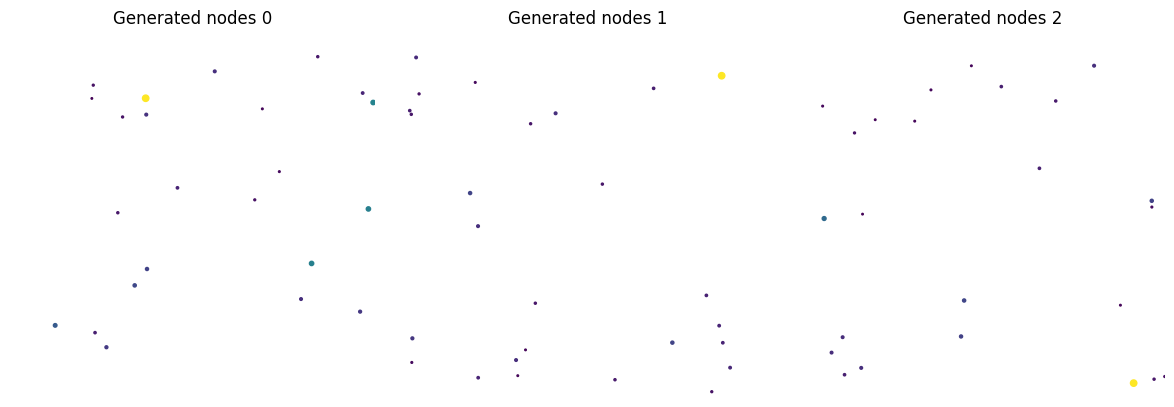

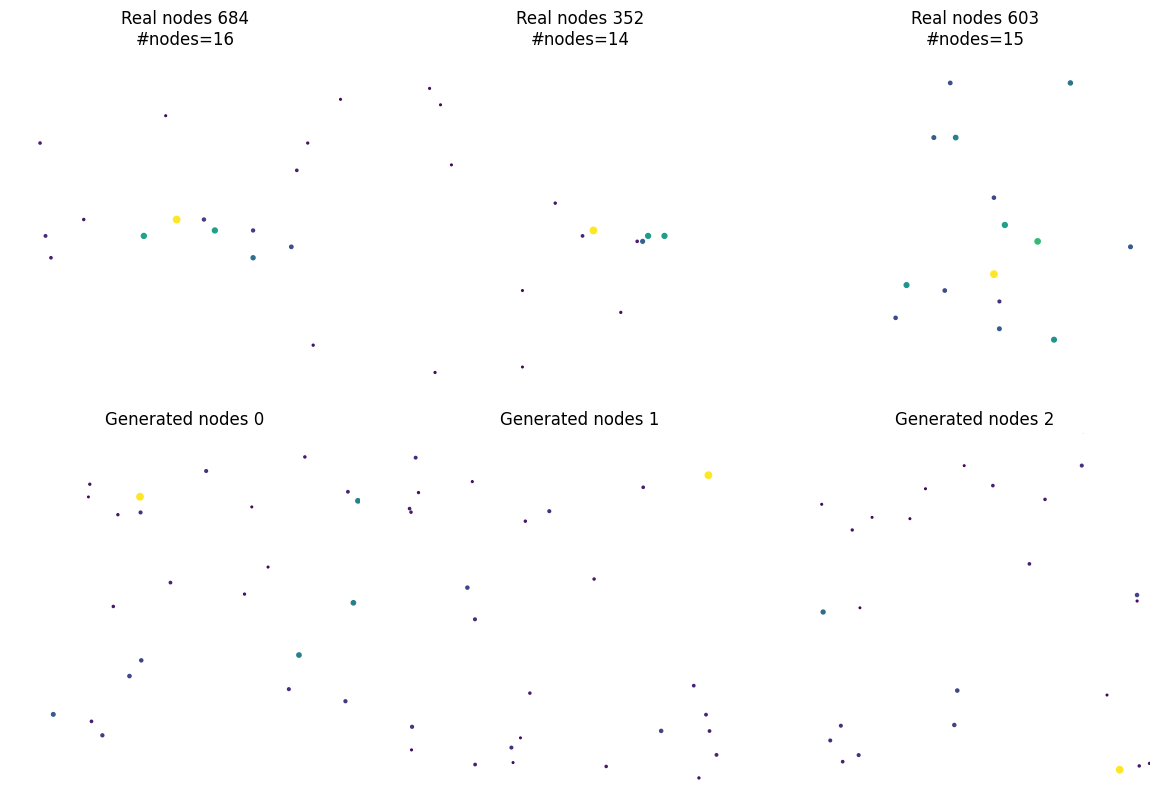

In [47]:
# --- Eval: sample from trained flow and visualize generated nodes ---
def apply_constraints(x_flat):
    nodes = x_flat.view(-1, K_max, 3)
    nodes_xy = torch.tanh(nodes[..., 0:2])
    logI = -F.softplus(nodes[..., 2:3])
    nodes = torch.cat([nodes_xy, logI], dim=-1)
    return nodes.view(-1, K_max * 3)

def flow_sample(model, num_samples, steps=50, device="cpu", counts=None, radials=None, radial_stds=None, centroids=None):
    """Simple Euler sampler for rectified flow."""
    model.eval()
    with torch.no_grad():
        if counts is None or radials is None or radial_stds is None or centroids is None:
            idx = torch.randint(0, counts_t.shape[0], (num_samples,), device=device)
            counts = counts_t[idx]
            radials = radials_t[idx]
            radial_stds = radial_stds_t[idx]
            centroids = centroids_t[idx]
        else:
            counts = counts.to(device).view(num_samples, 1)
            radials = radials.to(device).view(num_samples, 1)
            radial_stds = radial_stds.to(device).view(num_samples, 1)
            centroids = centroids.to(device)
            idx = torch.randint(0, counts_t.shape[0], (num_samples,), device=device)
            counts = counts_t[idx]
            radials = radials_t[idx]
            radial_stds = radial_stds_t[idx]
        # else:
        #     counts = counts.to(device).view(num_samples, 1)
        #     radials = radials.to(device).view(num_samples, 1)
        #     radial_stds = radial_stds.to(device).view(num_samples, 1)

        x = torch.randn(num_samples, dim, device=device)
        dt = 1.0 / steps
        for s in range(steps):
            t = torch.full((num_samples, 1), s / steps, device=device)
            v, _ = model(x, t, counts, radials, radial_stds, centroids)
            x = x + v * dt
        x = apply_constraints(x)
    return x, counts, radials, radial_stds, centroids

def predict_mask_logits(model, x_flat, counts, radials, radial_stds, centroids):
    model.eval()
    with torch.no_grad():
        t0 = torch.zeros(x_flat.shape[0], 1, device=x_flat.device)
        _, mask_logits = model(x_flat, t0, counts, radials, radial_stds, centroids)
        mask = torch.sigmoid(mask_logits)
    return mask, mask_logits

def unflatten_nodes(x_flat, K_max):
    return x_flat.view(-1, K_max, 3)

def plot_generated_nodes(ax, nodes, mask=None, mask_logits=None, count=None, center=None, cmap="viridis"):
    # nodes: (K,3) with x,y in [-1,1], log-intensity in (−inf, 0]
    xs = nodes[:, 0]
    ys = nodes[:, 1]
    intens = torch.exp(nodes[:, 2])

    if count is not None and mask_logits is not None:
        k = max(1, int(round(float(count) * K_max)))
        topk = torch.topk(mask_logits, k=k, dim=0).indices
        keep = torch.zeros_like(mask_logits, dtype=torch.bool)
        keep[topk] = True
        xs = xs[keep]
        ys = ys[keep]
        intens = intens[keep]
    elif mask is not None:
        keep = mask > 0.5
        xs = xs[keep]
        ys = ys[keep]
        intens = intens[keep]

    if intens.numel() == 0:
        ax.axis("off")
        ax.set_title("(empty)")
        return

    # add centroid back (if provided)
    if center is not None:
        xs = xs + center[0]
        ys = ys + center[1]
    # map to image coordinates
    xs = (xs + 1.0) * 0.5 * (data_X.shape[2] - 1)
    ys = (ys + 1.0) * 0.5 * (data_X.shape[1] - 1)

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(xs.cpu().numpy(), ys.cpu().numpy(), s=sizes.cpu().numpy(), c=intens.cpu().numpy(),
               cmap=cmap, vmin=0, vmax=float(intens.max().cpu()))
    ax.set_xlim(-0.5, data_X.shape[2] - 0.5)
    ax.set_ylim(data_X.shape[1] - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

num_gen = 3
gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers = flow_sample(model, num_gen, steps=50, device=device)
gen_centers = centroids_t[torch.randint(0, centroids_t.shape[0], (num_gen,))].to(device)
gen_mask, gen_mask_logits = predict_mask_logits(model, gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers)
gen_nodes = unflatten_nodes(gen_flat, K_max)

fig, axes = plt.subplots(1, num_gen, figsize=(4 * num_gen, 4))
if num_gen == 1:
    axes = [axes]

for i in range(num_gen):
    plot_generated_nodes(axes[i], gen_nodes[i], mask=gen_mask[i], mask_logits=gen_mask_logits[i], count=gen_counts[i], center=gen_centers[i])
    axes[i].set_title(f"Generated nodes {i}")

plt.tight_layout()
plt.show()

# --- Plot a few original node graphs alongside ---
num_real = num_gen
real_idx = np.random.choice(data_X.shape[0], size=num_real, replace=False)

fig, axes = plt.subplots(2, num_real, figsize=(4 * num_real, 8))
if num_real == 1:
    axes = np.array([axes]).reshape(2, 1)

for i in range(num_real):
    # real
    sample = _to_single_channel(data_X[real_idx[i]], channel=0)
    n_nodes = plot_energy_nodes(axes[0, i], sample, energy_quantile=energy_quantile)
    axes[0, i].set_title(f"Real nodes {real_idx[i]}\n#nodes={n_nodes}")

    # generated
    plot_generated_nodes(axes[1, i], gen_nodes[i], mask=gen_mask[i], mask_logits=gen_mask_logits[i], count=gen_counts[i], center=gen_centers[i])
    axes[1, i].set_title(f"Generated nodes {i}")

plt.tight_layout()
plt.show()


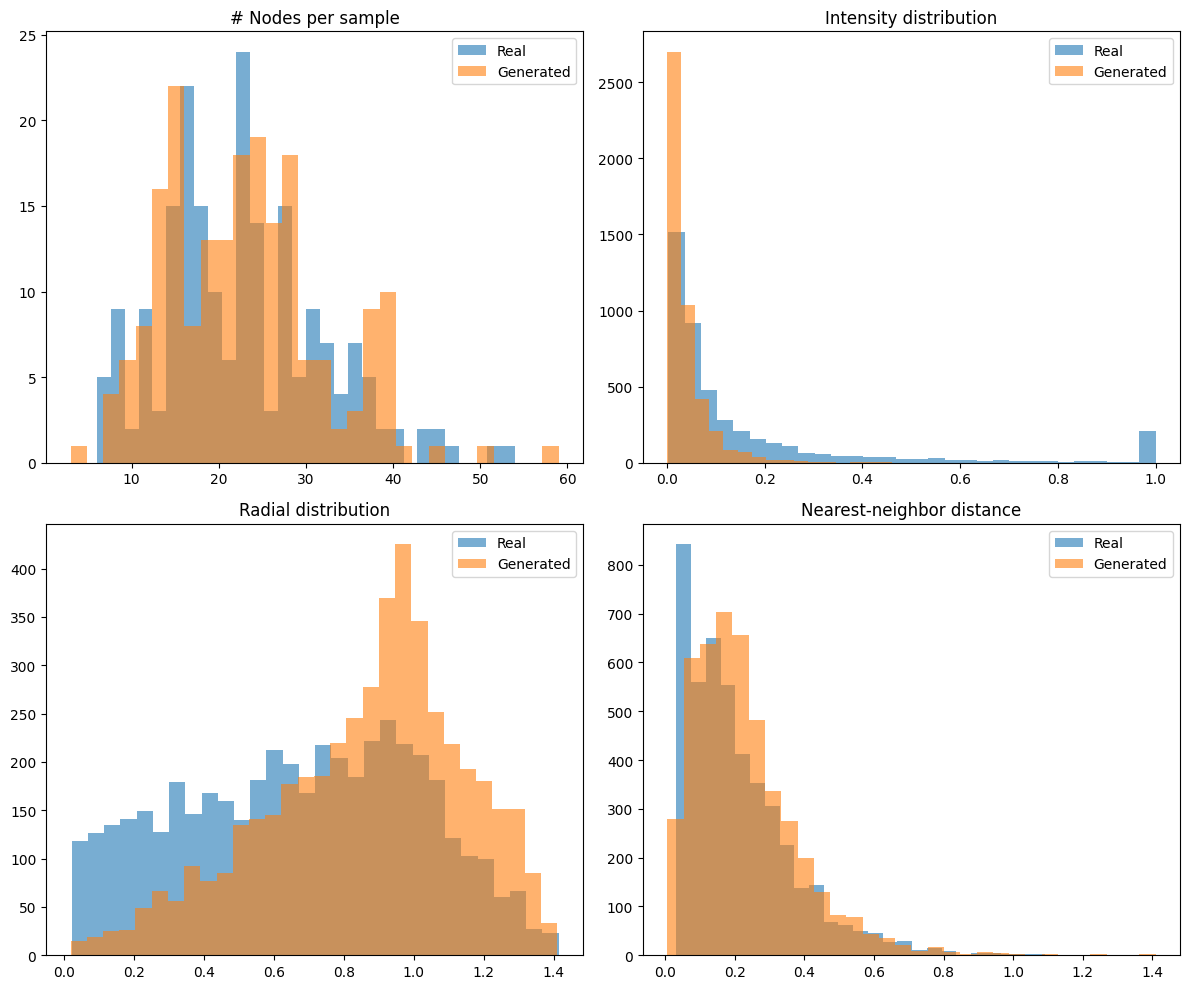

In [48]:
# --- Foreground-only quantitative evals (real vs generated) ---
import numpy as np

def nodes_from_real_sample(idx, energy_quantile=0.995):
    sample = _to_single_channel(data_X[idx], channel=0)
    img_n, coords, intens = extract_energy_nodes(sample, energy_quantile=energy_quantile)
    # coords: (N,2) in (row, col)
    H, W = img_n.shape
    if intens.size == 0:
        return np.empty((0, 3))
    xs = coords[:, 1] / (W - 1 + 1e-12)
    ys = coords[:, 0] / (H - 1 + 1e-12)
    xs = 2.0 * xs - 1.0
    ys = 2.0 * ys - 1.0
    return np.stack([xs, ys, intens], axis=1)

def nodes_from_generated(gen_nodes_i, gen_mask_i, gen_mask_logits_i, count):
    # gen_nodes_i: (K,3) in [-1,1] with log-intensity
    nodes = gen_nodes_i.detach().cpu().numpy()
    if gen_mask_logits_i is not None:
        k = max(1, int(round(float(count) * K_max)))
        topk = torch.topk(gen_mask_logits_i, k=k, dim=0).indices
        keep = np.zeros((K_max,), dtype=bool)
        keep[topk.cpu().numpy()] = True
    else:
        keep = (gen_mask_i.detach().cpu().numpy() > 0.5)
    nodes = nodes[keep]
    if nodes.size == 0:
        return nodes
    nodes[:, 2] = np.exp(nodes[:, 2])
    return nodes

def radial_dist(nodes):
    if nodes.shape[0] == 0:
        return np.array([])
    xs, ys = nodes[:, 0], nodes[:, 1]
    return np.sqrt(xs**2 + ys**2)

def nearest_neighbor_dist(nodes):
    if nodes.shape[0] < 2:
        return np.array([])
    pts = nodes[:, :2]
    dists = []
    for i in range(len(pts)):
        diff = pts - pts[i]
        dist = np.sqrt((diff**2).sum(axis=1))
        dist[i] = np.inf
        dists.append(dist.min())
    return np.array(dists)

# Build evaluation sets
num_eval = min(200, data_X.shape[0])
real_idx = np.random.choice(data_X.shape[0], size=num_eval, replace=False)
real_nodes_list = [nodes_from_real_sample(i, energy_quantile=energy_quantile) for i in real_idx]

gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers = flow_sample(model, num_eval, steps=50, device=device)
gen_mask, gen_mask_logits = predict_mask_logits(model, gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers)
gen_nodes = unflatten_nodes(gen_flat, K_max)
gen_nodes_list = [nodes_from_generated(gen_nodes[i], gen_mask[i], gen_mask_logits[i], gen_counts[i]) for i in range(num_eval)]

# 1) Node count distribution
real_counts = np.array([n.shape[0] for n in real_nodes_list])
gen_counts = np.array([n.shape[0] for n in gen_nodes_list])

# 2) Intensity distribution
real_intens = np.concatenate([n[:, 2] for n in real_nodes_list if n.shape[0] > 0])
gen_intens = np.concatenate([n[:, 2] for n in gen_nodes_list if n.shape[0] > 0])

# 3) Radial distribution
real_r = np.concatenate([radial_dist(n) for n in real_nodes_list if n.shape[0] > 0])
gen_r = np.concatenate([radial_dist(n) for n in gen_nodes_list if n.shape[0] > 0])

# 4) Nearest-neighbor distances
real_nn = np.concatenate([nearest_neighbor_dist(n) for n in real_nodes_list if n.shape[0] > 1])
gen_nn = np.concatenate([nearest_neighbor_dist(n) for n in gen_nodes_list if n.shape[0] > 1])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(real_counts, bins=30, alpha=0.6, label="Real")
axes[0, 0].hist(gen_counts, bins=30, alpha=0.6, label="Generated")
axes[0, 0].set_title("# Nodes per sample")
axes[0, 0].legend()

axes[0, 1].hist(real_intens, bins=30, alpha=0.6, label="Real")
axes[0, 1].hist(gen_intens, bins=30, alpha=0.6, label="Generated")
axes[0, 1].set_title("Intensity distribution")
axes[0, 1].legend()

axes[1, 0].hist(real_r, bins=30, alpha=0.6, label="Real")
axes[1, 0].hist(gen_r, bins=30, alpha=0.6, label="Generated")
axes[1, 0].set_title("Radial distribution")
axes[1, 0].legend()

axes[1, 1].hist(real_nn, bins=30, alpha=0.6, label="Real")
axes[1, 1].hist(gen_nn, bins=30, alpha=0.6, label="Generated")
axes[1, 1].set_title("Nearest-neighbor distance")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


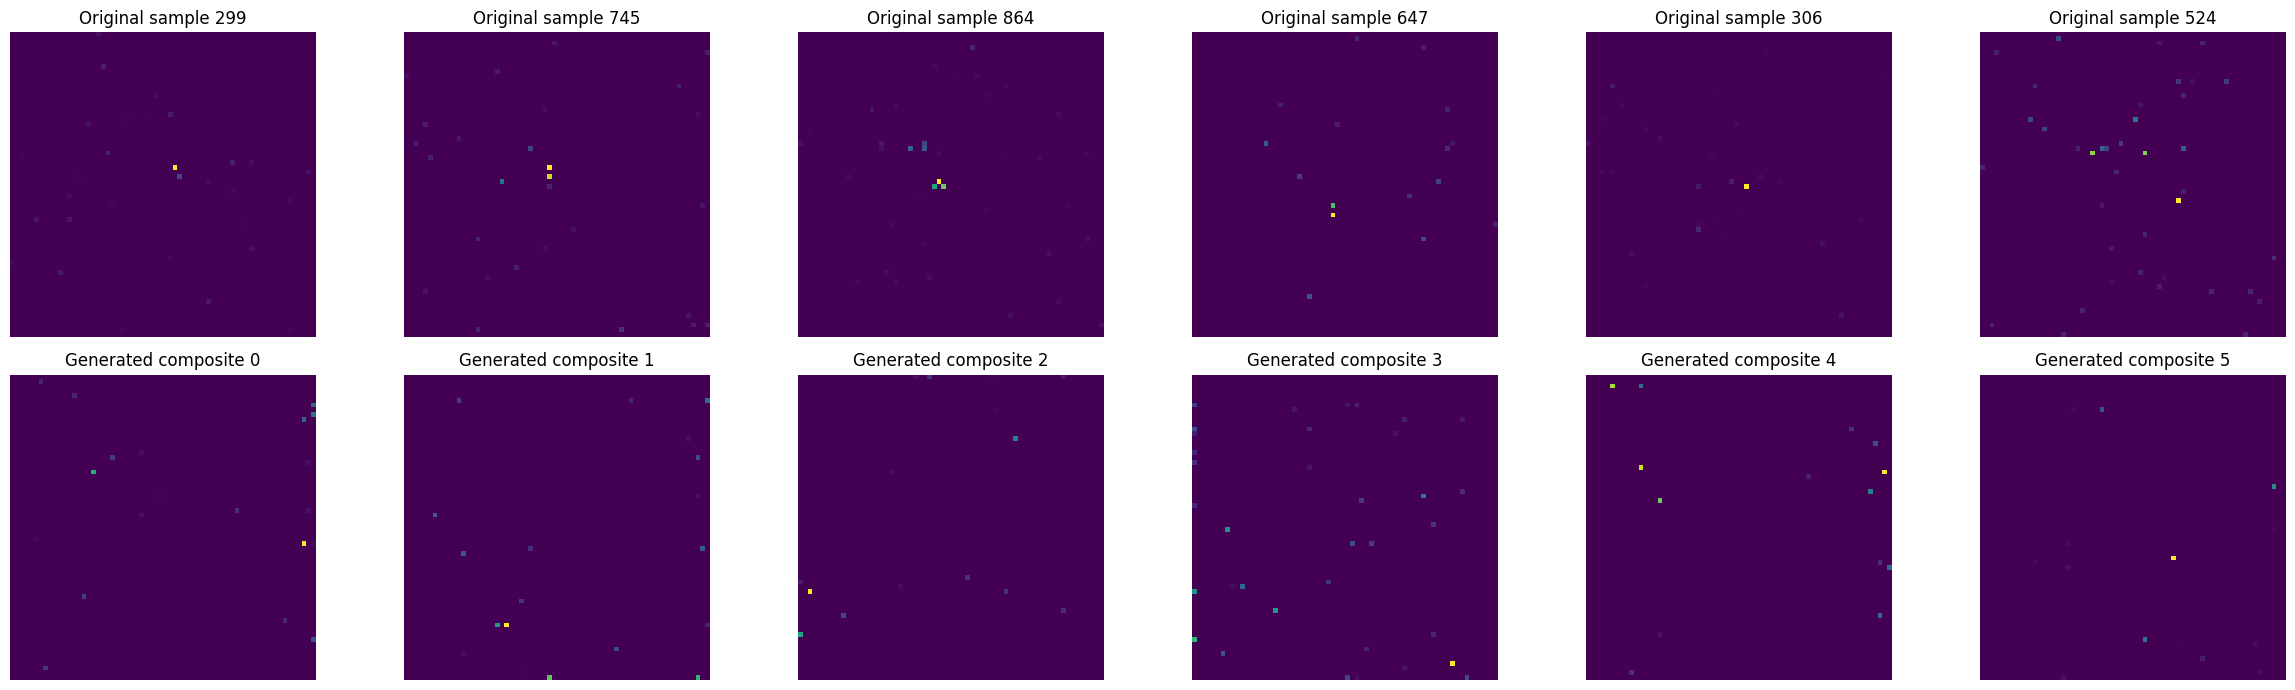

In [49]:
# --- Paste generated foreground nodes onto empty background ---
def empty_background(H, W):
    return np.zeros((H, W), dtype=np.float32)

def nodes_to_foreground_image(nodes, mask_logits, count, H, W):
    # nodes: (K,3) with x,y in [-1,1], log-intensity in (−inf, 0]
    k = max(1, int(round(float(count) * K_max)))
    topk = torch.topk(mask_logits, k=k, dim=0).indices
    nodes = nodes[topk]

    xs = nodes[:, 0]
    ys = nodes[:, 1]
    intens = torch.exp(nodes[:, 2])

    xs_pix = torch.clamp(((xs + 1.0) * 0.5 * (W - 1)).round(), 0, W - 1).long()
    ys_pix = torch.clamp(((ys + 1.0) * 0.5 * (H - 1)).round(), 0, H - 1).long()

    fg = np.zeros((H, W), dtype=np.float32)
    for x, y, val in zip(xs_pix.cpu().numpy(), ys_pix.cpu().numpy(), intens.cpu().numpy()):
        fg[y, x] += val
    fg = np.clip(fg, 0.0, 1.0)
    return fg

num_comp = 6
gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers = flow_sample(model, num_comp, steps=50, device=device)
gen_mask, gen_mask_logits = predict_mask_logits(model, gen_flat, gen_counts, gen_radials, gen_radial_stds, gen_centers)
gen_nodes = unflatten_nodes(gen_flat, K_max)

fig, axes = plt.subplots(2, num_comp, figsize=(4 * num_comp, 7))
if num_comp == 1:
    axes = np.array([axes]).reshape(2, 1)

for i in range(num_comp):
    # choose a random real sample for comparison
    idx = np.random.randint(0, data_X.shape[0])
    sample = _to_single_channel(data_X[idx], channel=0)
    H, W = sample.shape

    bg = empty_background(H, W)
    # add centroid back before rasterizing
    nodes_i = gen_nodes[i].clone()
    nodes_i[:, 0] = nodes_i[:, 0] + gen_centers[i, 0]
    nodes_i[:, 1] = nodes_i[:, 1] + gen_centers[i, 1]
    fg = nodes_to_foreground_image(nodes_i, gen_mask_logits[i], gen_counts[i], H, W)
    composite = np.clip(bg + fg, 0.0, 1.0)

    axes[0, i].imshow(_normalize_for_graph(sample), cmap="viridis")
    axes[0, i].set_title(f"Original sample {idx}")
    axes[0, i].axis("off")

    axes[1, i].imshow(composite, cmap="viridis")
    axes[1, i].set_title(f"Generated composite {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [50]:
# --- Quick experiment: quantum angle encoding of node features ---
angle_scale = np.pi / 2.0
logI_scale = np.abs(nodes_all[..., 2]).max() + 1e-12

def encode_nodes_angle(nodes):
    """Analytic single-qubit angle encoding: (sin, cos) per feature."""
    x = nodes[..., 0]
    y = nodes[..., 1]
    logI = nodes[..., 2] / logI_scale
    logI = np.clip(logI, -1.0, 1.0)

    enc = np.stack([
        np.sin(angle_scale * x), np.cos(angle_scale * x),
        np.sin(angle_scale * y), np.cos(angle_scale * y),
        np.sin(angle_scale * logI), np.cos(angle_scale * logI),
    ], axis=-1).astype(np.float32)
    return enc

encoded_nodes_all = encode_nodes_angle(nodes_all)
encoded_nodes_t = torch.tensor(encoded_nodes_all, dtype=torch.float32)
print("Encoded nodes:", encoded_nodes_t.shape)


Encoded nodes: torch.Size([1000, 256, 6])


In [54]:
# --- Train flow on quantum-encoded nodes (same architecture) ---
device = "mps" if torch.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

features_per_node_q = 6
dim_q = K_max * features_per_node_q

x0_q = encoded_nodes_t.view(encoded_nodes_t.shape[0], -1).to(device)
mask_flat_q = mask_t.view(mask_t.shape[0], -1).to(device)
mask_feat_q = mask_flat_q.repeat_interleave(features_per_node_q, dim=1)
counts_q = counts_t.to(device)
radials_q = radials_t.to(device)
radial_stds_q = radial_stds_t.to(device)
centroids_q = centroids_t.to(device)

class QuantumFlowMLP(nn.Module):
    def __init__(self, dim, nodes, hidden=512, time_dim=64, count_dim=32, radial_dim=16, radial_std_dim=16, centroid_dim=16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(dim + time_dim + count_dim + radial_dim + radial_std_dim + 2 * centroid_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )
        self.v_head = nn.Linear(hidden, dim)
        self.mask_head = nn.Linear(hidden, nodes)

    def forward(self, x, t, c, r, rs, cxy):
        t_emb = timestep_embedding(t)
        c_emb = count_embedding(c)
        r_emb = radial_embedding(r)
        rs_emb = radial_std_embedding(rs)
        cxy_emb = centroid_embedding(cxy)
        h = torch.cat([x, t_emb, c_emb, r_emb, rs_emb, cxy_emb], dim=-1)
        h = self.backbone(h)
        v = self.v_head(h)
        mask_logits = self.mask_head(h)
        return v, mask_logits

q_model = QuantumFlowMLP(dim=dim_q, nodes=K_max).to(device)
q_opt = torch.optim.Adam(q_model.parameters(), lr=1e-4)

def normalize_pair(s, c):
    norm = torch.sqrt(s**2 + c**2) + 1e-12
    return s / norm, c / norm

def decode_nodes_angle(enc_nodes):
    # enc_nodes: (B,K,6)
    sx, cx = normalize_pair(enc_nodes[..., 0], enc_nodes[..., 1])
    sy, cy = normalize_pair(enc_nodes[..., 2], enc_nodes[..., 3])
    si, ci = normalize_pair(enc_nodes[..., 4], enc_nodes[..., 5])
    x = torch.atan2(sx, cx) / angle_scale
    x = torch.tanh(x)  # keep in [-1, 1]
    y = torch.atan2(sy, cy) / angle_scale
    y = torch.tanh(y)
    logI_scaled = torch.atan2(si, ci) / angle_scale
    logI = logI_scaled * logI_scale
    logI = torch.clamp(logI, -logI_scale, 0.0)
    return x, y, logI

batch_size_q = 16
num_steps_q = 500
mask_weight_q = 1.0
count_weight_q = 1.0
radial_weight_q = 1.0
nn_weight_q = 1.0
shrink_weight_q = 0.5
radial_hist_weight_q = 0.5

for step in range(num_steps_q):
    idx = torch.randint(0, x0_q.shape[0], (batch_size_q,), device=device)
    x = x0_q[idx]
    m_feat = mask_feat_q[idx]
    m = mask_flat_q[idx]
    c = counts_q[idx]
    r = radials_q[idx]
    rs = radial_stds_q[idx]
    cxy = centroids_q[idx]
    t = torch.rand(batch_size_q, 1, device=device)

    x1 = torch.randn_like(x)
    xt = (1 - t) * x + t * x1
    v_target = x1 - x
    v_pred, mask_logits = q_model(xt, t, c, r, rs, cxy)

    # Masked flow loss in encoded space
    loss_flow = ((v_pred - v_target) ** 2 * m_feat).sum() / (m_feat.sum() + 1e-12)
    loss_mask = F.binary_cross_entropy_with_logits(mask_logits, m)
    count_pred = torch.sigmoid(mask_logits).sum(dim=1, keepdim=True) / K_max
    loss_count = ((count_pred - c) ** 2).mean()

    # Decode for geometric losses
    x0_hat = xt - t * v_pred
    enc_hat = x0_hat.view(-1, K_max, features_per_node_q)
    xs_hat, ys_hat, logI_hat = decode_nodes_angle(enc_hat)
    intens_hat = torch.exp(logI_hat) * m
    w_sum = intens_hat.sum(dim=1, keepdim=True) + 1e-12
    r_hat = torch.sqrt(xs_hat**2 + ys_hat**2) / np.sqrt(2.0)
    r_mean_hat = (r_hat * intens_hat).sum(dim=1, keepdim=True) / w_sum
    r_var_hat = ((r_hat - r_mean_hat)**2 * intens_hat).sum(dim=1, keepdim=True) / w_sum
    r_std_hat = torch.sqrt(r_var_hat + 1e-12)
    loss_radial = ((r_mean_hat - r) ** 2 + (r_std_hat - rs) ** 2).mean()
    loss_shrink = (r_hat * intens_hat).sum(dim=1).mean()

    # Radial histogram loss
    nbins = 10
    bins = torch.linspace(0.0, 1.0, nbins + 1, device=r_hat.device)
    hist_loss = 0.0
    for b in range(nbins):
        in_bin = (r_hat >= bins[b]) & (r_hat < bins[b + 1])
        bin_mass = (intens_hat * in_bin.float()).sum(dim=1, keepdim=True) / w_sum
        bin_target = (r >= bins[b]) & (r < bins[b + 1])
        bin_target = bin_target.float()
        hist_loss += ((bin_mass - bin_target) ** 2).mean()
    loss_hist = hist_loss / nbins

    # NN loss
    coords_hat = torch.stack([xs_hat, ys_hat], dim=-1)
    dist = torch.cdist(coords_hat, coords_hat)
    eye = torch.eye(K_max, device=dist.device).unsqueeze(0)
    dist = dist + eye * 1e9
    mask_pair = (m > 0.5).unsqueeze(2) & (m > 0.5).unsqueeze(1)
    dist = dist + (~mask_pair).float() * 1e9
    nn_hat = dist.min(dim=2).values
    nn_mean_hat = (nn_hat * (m > 0.5)).sum(dim=1, keepdim=True) / ((m > 0.5).sum(dim=1, keepdim=True) + 1e-12)
    loss_nn = ((nn_mean_hat - nn_means_t[idx]) ** 2).mean()

    loss = (loss_flow + mask_weight_q * loss_mask + count_weight_q * loss_count
            + radial_weight_q * loss_radial + nn_weight_q * loss_nn
            + shrink_weight_q * loss_shrink + radial_hist_weight_q * loss_hist)

    q_opt.zero_grad()
    loss.backward()
    q_opt.step()

    if step % 25 == 0:
        print(f"[Q] Step {step}: loss={loss.item():.6f}")


Using device: mps
[Q] Step 0: loss=5.606829
[Q] Step 25: loss=5.499640
[Q] Step 50: loss=3.344832
[Q] Step 75: loss=2.459089
[Q] Step 100: loss=2.264422
[Q] Step 125: loss=1.967683
[Q] Step 150: loss=1.992256
[Q] Step 175: loss=1.789405
[Q] Step 200: loss=1.873896
[Q] Step 225: loss=1.864365
[Q] Step 250: loss=1.808860
[Q] Step 275: loss=1.816124
[Q] Step 300: loss=1.809803
[Q] Step 325: loss=1.808125
[Q] Step 350: loss=1.806154
[Q] Step 375: loss=1.786667
[Q] Step 400: loss=1.968893
[Q] Step 425: loss=1.682976
[Q] Step 450: loss=1.930850
[Q] Step 475: loss=1.997029


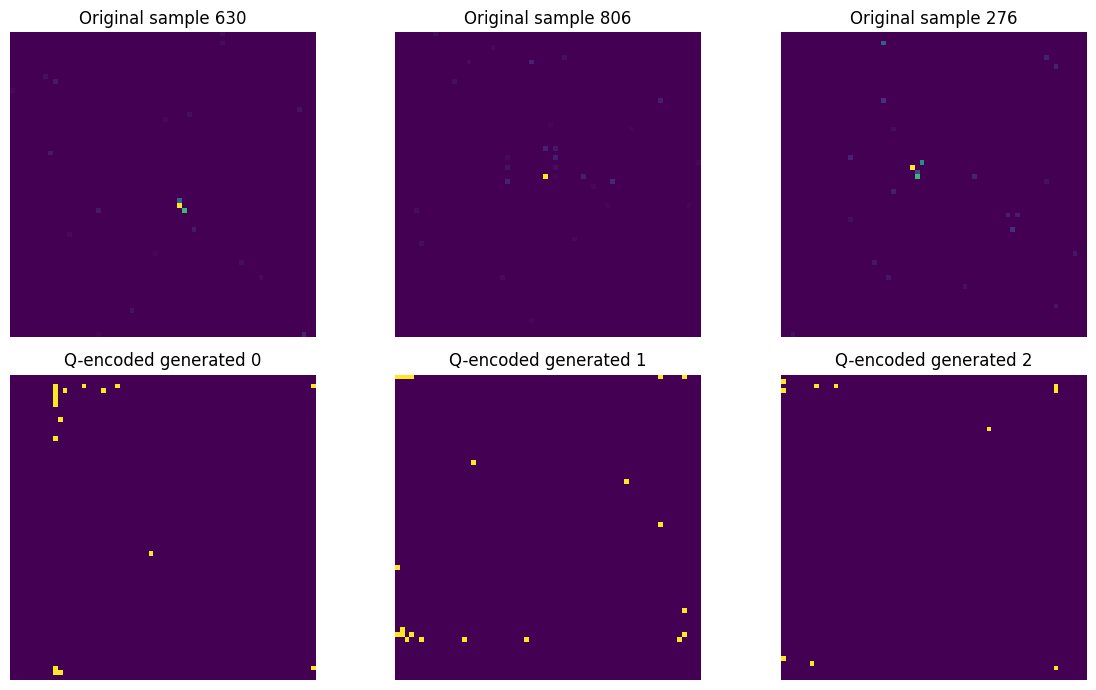

In [55]:
# --- Eval quantum-encoded model: generate, decode, compose ---
def apply_constraints_q(x_flat):
    enc = x_flat.view(-1, K_max, 6)
    # normalize sin/cos pairs
    def norm_pair(s, c):
        norm = torch.sqrt(s**2 + c**2) + 1e-12
        return s / norm, c / norm
    enc[..., 0], enc[..., 1] = norm_pair(enc[..., 0], enc[..., 1])
    enc[..., 2], enc[..., 3] = norm_pair(enc[..., 2], enc[..., 3])
    enc[..., 4], enc[..., 5] = norm_pair(enc[..., 4], enc[..., 5])
    return enc.view(-1, K_max * 6)

def flow_sample_q(model, num_samples, steps=50, device="cpu"):
    model.eval()
    with torch.no_grad():
        idx = torch.randint(0, counts_t.shape[0], (num_samples,), device=device)
        counts = counts_t[idx]
        radials = radials_t[idx]
        radial_stds = radial_stds_t[idx]
        centers = centroids_t[idx]

        x = torch.randn(num_samples, dim_q, device=device)
        dt = 1.0 / steps
        for s in range(steps):
            t = torch.full((num_samples, 1), s / steps, device=device)
            v, _ = q_model(x, t, counts, radials, radial_stds, centers)
            x = x + v * dt
        x = apply_constraints_q(x)
    return x, counts, radials, radial_stds, centers

def predict_mask_logits_q(model, x_flat, counts, radials, radial_stds, centers):
    model.eval()
    with torch.no_grad():
        t0 = torch.zeros(x_flat.shape[0], 1, device=x_flat.device)
        _, mask_logits = model(x_flat, t0, counts, radials, radial_stds, centers)
        mask = torch.sigmoid(mask_logits)
    return mask, mask_logits

def decode_generated_nodes(enc_nodes):
    sx, cx = normalize_pair(enc_nodes[..., 0], enc_nodes[..., 1])
    sy, cy = normalize_pair(enc_nodes[..., 2], enc_nodes[..., 3])
    si, ci = normalize_pair(enc_nodes[..., 4], enc_nodes[..., 5])
    x = torch.atan2(sx, cx) / angle_scale
    x = torch.tanh(x)  # keep in [-1, 1]
    y = torch.atan2(sy, cy) / angle_scale
    y = torch.tanh(y)
    logI_scaled = torch.atan2(si, ci) / angle_scale
    logI = logI_scaled * logI_scale
    logI = torch.clamp(logI, -logI_scale, 0.0)
    return torch.stack([x, y, logI], dim=-1)

num_q = 3
q_flat, q_counts, q_rad, q_rstd, q_centers = flow_sample_q(q_model, num_q, steps=50, device=device)
q_mask, q_mask_logits = predict_mask_logits_q(q_model, q_flat, q_counts, q_rad, q_rstd, q_centers)
q_nodes_enc = q_flat.view(-1, K_max, 6)
q_nodes = decode_generated_nodes(q_nodes_enc)

fig, axes = plt.subplots(2, num_q, figsize=(4 * num_q, 7))
if num_q == 1:
    axes = np.array([axes]).reshape(2, 1)

for i in range(num_q):
    # original sample
    idx = np.random.randint(0, data_X.shape[0])
    sample = _to_single_channel(data_X[idx], channel=0)
    axes[0, i].imshow(_normalize_for_graph(sample), cmap="viridis")
    axes[0, i].set_title(f"Original sample {idx}")
    axes[0, i].axis("off")

    # generated composite (empty background)
    nodes_i = q_nodes[i].clone()
    nodes_i[:, 0] = nodes_i[:, 0] + q_centers[i, 0]
    nodes_i[:, 1] = nodes_i[:, 1] + q_centers[i, 1]
    fg = nodes_to_foreground_image(nodes_i, q_mask_logits[i], q_counts[i], sample.shape[0], sample.shape[1])
    axes[1, i].imshow(fg, cmap="viridis")
    axes[1, i].set_title(f"Q-encoded generated {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()
